#Упражнения: Раздел 5

In [31]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#autocorr из раздела
def autocorr(wave):
    lags = np.arange(len(wave.ys)//2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

#serial_corr из раздела
def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:n-lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]

#Упражнение 5.1

Оценка высоты тона чирпа для нескольких времен начала сегмента

In [55]:
#получаем вокальный чирп
if not os.path.exists('28042__bcjordan__voicedownbew.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/28042__bcjordan__voicedownbew.wav

np.float64(484.6153846153846)

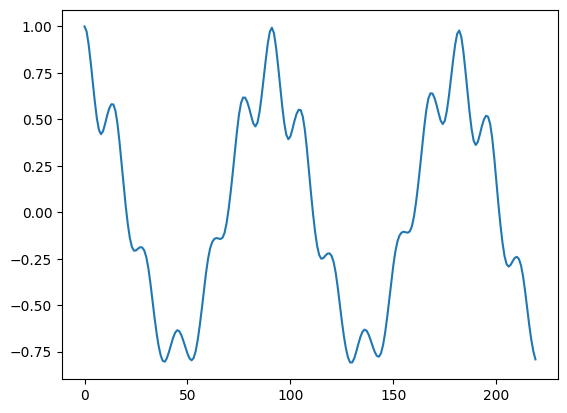

In [64]:
#получим сегмент 1
wave = tdsp.read_wave('28042__bcjordan__voicedownbew.wav')
duration = 0.01
seg1 = wave.segment(start=0.1, duration=duration)
#найдем оптимальный lag
lags, corrs = autocorr(seg1)
plt.plot(lags, corrs)
lag = np.array(corrs[50:150]).argmax() + 50
#найдем частоту тона
freq = 1 / (lag / seg1.framerate)
freq

np.float64(380.17241379310343)

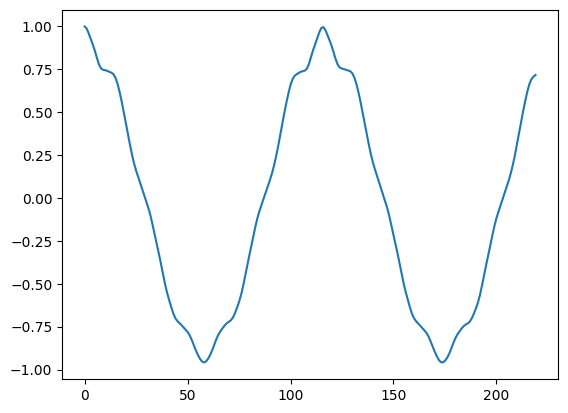

In [66]:
#получим сегмент 2
wave = tdsp.read_wave('28042__bcjordan__voicedownbew.wav')
duration = 0.01
seg2 = wave.segment(start=0.4, duration=duration)
#найдем оптимальный lag
lags, corrs = autocorr(seg2)
plt.plot(lags, corrs)
lag = np.array(corrs[50:150]).argmax() + 50
#найдем частоту тона
freq = 1 / (lag / seg1.framerate)
freq

##Упражнение 5.2

Функция estimate_fund с наложением на спектрограмму.

In [ ]:
#получаем wave
wave = tdsp.read_wave('28042__bcjordan__voicedownbew.wav')
wave.normalize()
wave.make_audio()

In [46]:
#функция estimate_fund
def estimate_fund(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    #если не будем обрезать corrs, поиск оптимального шага будет всегда 0
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

seg1 = wave.segment(start=0.2, duration=0.01)
freq = estimate_fund(seg1)
freq

np.float64(436.63366336633663)

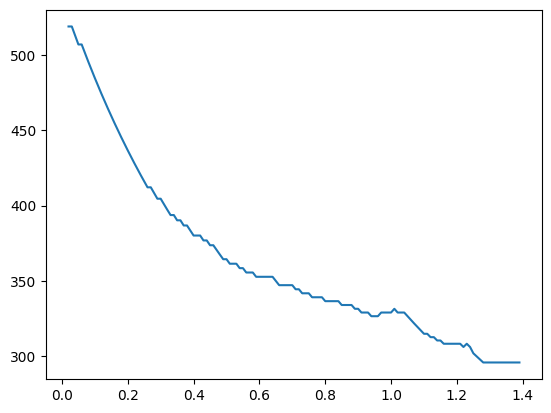

In [53]:
#создадим массив таких частот для шага 0.01
ts=[]
ys=[]

starts = np.arange(0.02, 1.4, 0.01)
for start in starts:
    seg1 = wave.segment(start=start, duration=0.01)
    freq = estimate_fund(seg1)
    ts.append(start)
    ys.append(freq)

plt.plot(ts, ys)

Получаем достаточно точные оценки частоты.

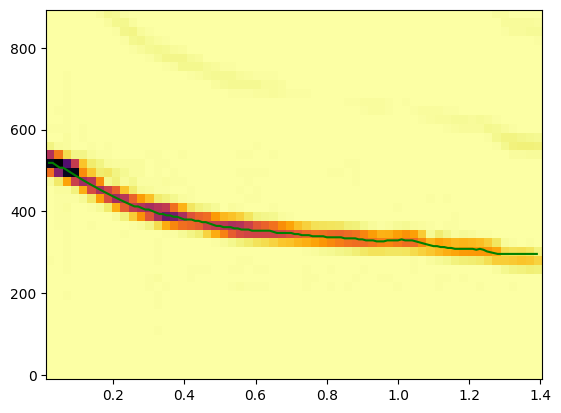

In [54]:
#наложим оценку частоты на спектрограмму
wave.make_spectrogram(2048).plot(high=900)
plt.plot(ts, ys, color="green")

##Упражнение 5.3

Автокорреляция цен BTC

In [68]:
if not os.path.exists('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv

--2026-05-13 04:26:32--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv [following]
--2026-05-13 04:26:32--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 143622 (140K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 140.26K  --.-KB/s    in 0.01s   



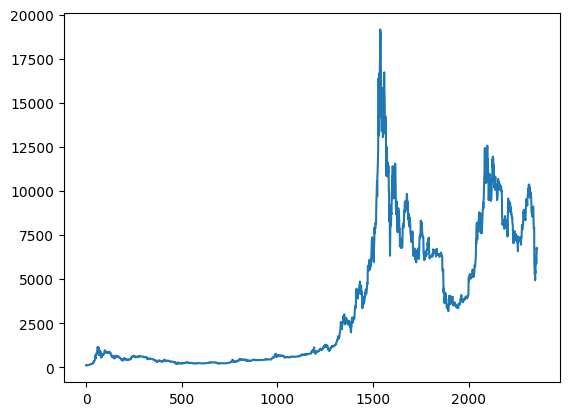

In [69]:
#используем pandas для чтения данных
import pandas as pd
data = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
                 parse_dates=[0])
ys = data['Closing Price (USD)']
ts = data.index
#создадим wave на основе этих данных
wave = tdsp.Wave(ys, ts, framerate=1)
wave.plot()

Выше уже описаны функции для автокорреляции autocorr() и serial_corr()

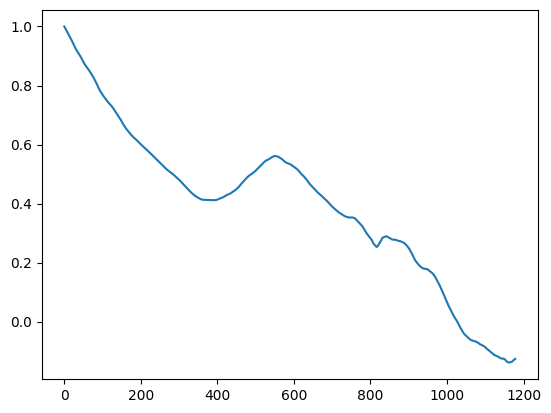

In [70]:
#получим автокорреляцию для wave
lags, corrs = autocorr(wave)
plt.plot(lags, corrs)

Автокорреляция спадает постепенно, что указывает на наличие зависимостей дальнего действия, однако не указывает на наличие периодичности в процессе (логически процесс также апериодичен).
